<a href="https://colab.research.google.com/github/Shiva-Kumar-S-M/AI-Based-Remote-Physiotherapy-and-Rehabilitation-Assistant/blob/main/deepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
pip install keras


In [66]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report



In [67]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

In [68]:
print("training images:",x_train.shape)
print("testing images:",x_test.shape)

training images: (60000, 28, 28)
testing images: (10000, 28, 28)


In [69]:
print("testing images:",x_train.shape)
print("testing images:",x_test.shape)

testing images: (60000, 28, 28)
testing images: (10000, 28, 28)


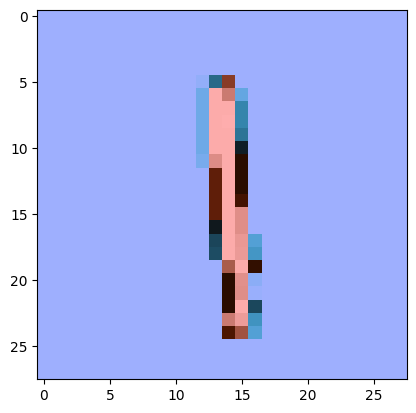

In [70]:
plt.imshow(x_train[8],cmap='berlin')
plt.show()

In [71]:
x_train = x_train/255.0
x_train = x_test/255.0

print("max pixel:",x_train.max())
print("min pixel:",x_train.min())

max pixel: 1.0
min pixel: 0.0


In [72]:
x_train=x_train.reshape(10000,784)
print(x_train[0])
print(y_train[:10])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [73]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(128,activation='relu',input_shape=(784,)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
history=model.fit(x_train,y_train,epochs=10,validation_split=0.2,batch_size=30)

Epoch 1/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1020 - loss: 2.3131 - val_accuracy: 0.1030 - val_loss: 2.3028
Epoch 2/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1169 - loss: 2.2962 - val_accuracy: 0.0975 - val_loss: 2.3199
Epoch 3/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1318 - loss: 2.2851 - val_accuracy: 0.1020 - val_loss: 2.3120
Epoch 4/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1474 - loss: 2.2671 - val_accuracy: 0.1155 - val_loss: 2.3138
Epoch 5/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1705 - loss: 2.2392 - val_accuracy: 0.1050 - val_loss: 2.3399
Epoch 6/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1935 - loss: 2.1984 - val_accuracy: 0.1120 - val_loss: 2.3593
Epoch 7/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2151 - loss: 2.1526 - val_accuracy: 0.1120 - val_loss: 2.4197
Epoch 8/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2456 - loss: 2.0925 - val_accuracy:

In [75]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


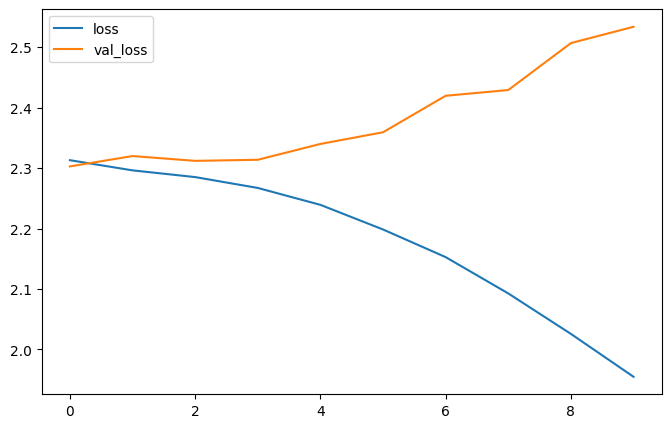

In [76]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

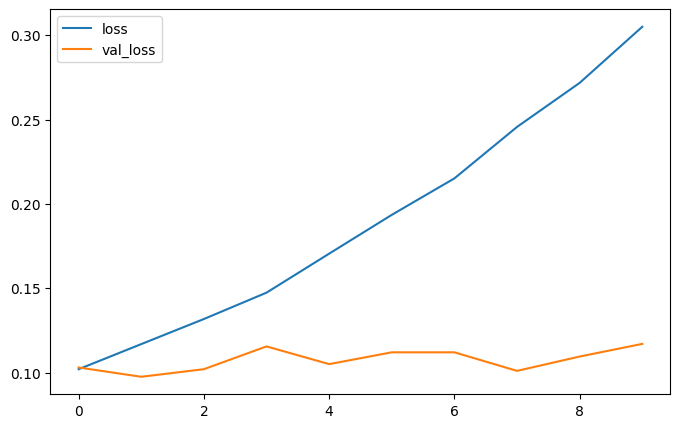

In [77]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='loss')
plt.plot(history.history['val_accuracy'],label='val_loss')
plt.legend()
plt.show()

In [86]:
x_test=x_test.reshape(-1,784)
y_pred=model.predict(x_test)
print(y_pred[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 8.4930988e-33
 0.0000000e+00 9.9999994e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00]


In [93]:
pred_label=np.argmax(y_pred,axis=1)
print("Pred Level ",pred_label)
print("actual value",y_test[0])

Pred Level  [6 0 8 ... 4 7 2]
actual value 7


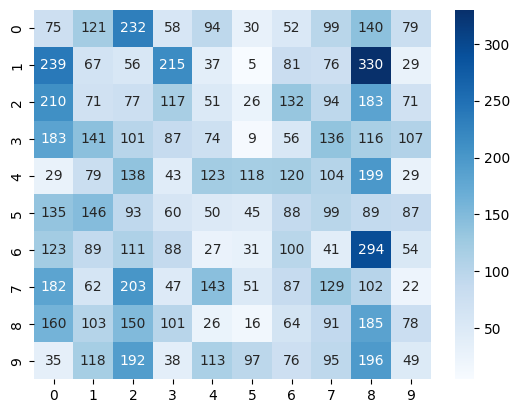

In [96]:
# y_pred_labels = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test,pred_label)

# plt.figure(figsize=(8,3))
import seaborn as sns
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.show()